# %% [markdown]
# # 02 — ΔV-EGA: Earth → (DSM) → Earth → Jupiter
# 
# Single Earth gravity assist with a deep space maneuver near aphelion to set up the
# return flyby. This is the simplest viable gravity-assist option for reaching Jupiter.
# The 2016 Europa Lander study baselined this class of trajectory.
#
# **Method:** MGA-1DSM global optimization via pykep + pygmo.
# One DSM is allowed per leg. The optimizer minimizes total ΔV 
# (departure V∞ + DSMs + arrival V∞).
#
# **IMPORTANT**: pykep's mga_1dsm decision vector stores velocities in **m/s**,
# even though the constructor accepts `vinf` bounds in km/s. All reporting
# below converts to km/s.

In [ ]:
# %% Cell 1 — Imports and setup
import numpy as np
import matplotlib.pyplot as plt
import pykep as pk
import pygmo as pg

print(f"pykep version: {pk.__version__}")
print(f"pygmo version: {pg.__version__}")

: 

In [9]:
# %% Cell 2 — Define the MGA-1DSM problem
#
# Sequence: Earth → Earth → Jupiter
# Leg 1 (E→E): Launch, DSM near aphelion, return to Earth flyby. Typically ~1.5-2.5 yr.
# Leg 2 (E→J): Post-flyby cruise to Jupiter, optional DSM. Typically ~2-5 yr.

seq = [
    pk.planet.jpl_lp('earth'),    # departure
    pk.planet.jpl_lp('earth'),    # flyby
    pk.planet.jpl_lp('jupiter'),  # arrival
]

udp = pk.trajopt.mga_1dsm(
    seq=seq,
    t0=[pk.epoch_from_string('2030-01-01 00:00:00'),
        pk.epoch_from_string('2038-01-01 00:00:00')],
    tof=[[200, 900],      # Leg 1: E→E (days) — ~0.5 to 2.5 years
         [400, 2200]],    # Leg 2: E→J (days) — ~1.1 to 6.0 years
    vinf=[0.5, 6.0],      # departure V∞ bounds (km/s)
    add_vinf_dep=True,     # include departure V∞ in objective
    add_vinf_arr=True,     # include Jupiter arrival V∞ in objective
    tof_encoding='direct',
    multi_objective=False,
)

prob = pg.problem(udp)
print(prob)

Problem name: MGA_1DSM Trajectory
	C++ class name: pybind11::object

	Global dimension:			10
	Integer dimension:			0
	Fitness dimension:			1
	Number of objectives:			1
	Equality constraints dimension:		0
	Inequality constraints dimension:	0
	Lower bounds: [10958, 0, 0, 500, 0.1, ... ]
	Upper bounds: [13880, 1, 1, 6000, 0.9, ... ]
	Has batch fitness evaluation: false

	Has gradient: false
	User implemented gradient sparsity: false
	Has hessians: false
	User implemented hessians sparsity: false

	Fitness evaluations: 0

	Thread safety: none

Extra info:

	 Sequence: ['earth', 'earth', 'jupiter']
	 Add launcher vinf to the objective?: True
	 Add final vinf to the objective?: True


In [10]:
# %% Cell 3 — Multi-restart global search
#
# MGA trajectory problems have many local minima. A single long optimization
# run often gets stuck. Instead, we launch many short random-start optimizations
# and collect the best seeds, then refine the top candidates.
#
# Strategy:
#   Phase 1 — Broad search: many islands, short evolution, collect champions
#   Phase 2 — Refinement: take top N solutions, run longer local optimization

# --- Phase 1: Broad search ---
print("Phase 1: Broad search (many short random starts) ...")

algo_phase1 = pg.algorithm(pg.sade(gen=150))
algo_phase1.set_verbosity(0)

# 64 islands × 20 individuals × 150 gen — fast but covers a lot of search space
archi = pg.archipelago(algo=algo_phase1, prob=prob, n=64, pop_size=20)

for i in range(5):
    archi.evolve()
    archi.wait()
    best_so_far = min(isl.get_population().champion_f[0] for isl in archi)
    print(f"  Round {i+1}/5: best = {best_so_far/1000:.4f} km/s")  # convert m/s to km/s

# Collect all champion solutions
phase1_f = [isl.get_population().champion_f[0] for isl in archi]
phase1_x = [isl.get_population().champion_x for isl in archi]

# Sort by fitness and take top 20 seeds
ranked = sorted(zip(phase1_f, phase1_x), key=lambda pair: pair[0])
top_seeds = ranked[:20]
print(f"\nPhase 1 complete. Top 5 solutions (km/s):")
for i, (f, x) in enumerate(top_seeds[:5]):
    print(f"  #{i+1}: {f/1000:.4f} km/s")

# --- Phase 2: Refine top seeds ---
print("\nPhase 2: Refining top 20 solutions ...")

algo_phase2 = pg.algorithm(pg.sade(gen=500))
algo_phase2.set_verbosity(0)

best_overall_f = float('inf')
best_overall_x = None

for i, (f_seed, x_seed) in enumerate(top_seeds):
    # Create a population seeded with this solution
    pop = pg.population(prob, size=20)
    pop.set_x(0, x_seed)  # inject seed as first individual
    
    # Evolve
    pop = algo_phase2.evolve(pop)
    
    if pop.champion_f[0] < best_overall_f:
        best_overall_f = pop.champion_f[0]
        best_overall_x = pop.champion_x.copy()
    
    if (i + 1) % 5 == 0:
        print(f"  Refined {i+1}/20 seeds, best so far: {best_overall_f/1000:.4f} km/s")

# --- Phase 3: Final polish with Compass Search (local optimizer) ---
print("\nPhase 3: Local refinement with Compass Search ...")

algo_local = pg.algorithm(pg.compass_search(max_fevals=50000, start_range=0.01, stop_range=1e-6))
algo_local.set_verbosity(0)

pop_final = pg.population(prob, size=1)
pop_final.set_x(0, best_overall_x)
pop_final = algo_local.evolve(pop_final)

best_f = pop_final.champion_f[0]
best_x = pop_final.champion_x.copy()

print(f"\nFinal best ΔV: {best_f/1000:.4f} km/s")

Phase 1: Broad search (many short random starts) ...
  Round 1/5: best = 16.8101 km/s
  Round 2/5: best = 16.8101 km/s
  Round 3/5: best = 16.8101 km/s
  Round 4/5: best = 16.8101 km/s
  Round 5/5: best = 16.8101 km/s

Phase 1 complete. Top 5 solutions (km/s):
  #1: 16.8101 km/s
  #2: 19.0675 km/s
  #3: 19.9540 km/s
  #4: 20.0604 km/s
  #5: 20.0612 km/s

Phase 2: Refining top 20 solutions ...
  Refined 5/20 seeds, best so far: 13.7012 km/s
  Refined 10/20 seeds, best so far: 13.6136 km/s
  Refined 15/20 seeds, best so far: 13.5851 km/s
  Refined 20/20 seeds, best so far: 13.5851 km/s

Phase 3: Local refinement with Compass Search ...

Final best ΔV: 11.8350 km/s


In [12]:
# %% Cell 4 — Display best solution
print("=" * 60)
print("  ΔV-EGA — BEST SOLUTION")
print("=" * 60)
udp.pretty(best_x)
print("=" * 60)
print(f"\n  Objective (total ΔV): {best_f/1000:.4f} km/s")

  ΔV-EGA — BEST SOLUTION
First Leg: earth to earth
Departure: 2037-Sep-19 13:38:24.028575 (13776.56833366406 mjd2000) 
Duration: 471.90831658427044days
VINF: 1.1003275795547065 km/sec
DSM after 207.53154464635256 days
DSM magnitude: 1449.248436476147m/s

leg no. 2: earth to jupiter
Duration: 1760.5261614436147days
Fly-by epoch: 2039-Jan-04 11:26:22.581456 (14248.47665024833 mjd2000) 
Fly-by radius: 1.1 planetary radii
DSM after 735.8249382532017 days
DSM magnitude: 3609.9399380417603m/s

Arrival at jupiter
Arrival epoch: 2043-Oct-31 00:04:02.930184 (16009.002811691946 mjd2000) 
Arrival Vinf: 5675.496434153014m/s
Total mission time: 6.112072492889487 years (2232.4344780278852 days)

  Objective (total ΔV): 11.8350 km/s


In [13]:
# %% Cell 5 — Extract key values for trade study
#
# Decision vector for mga_1dsm (direct encoding, 2 legs):
#   [t0, u, v, Vinf, eta1, T1, beta2, rp2/rV2, eta2, T2]
# where t0 is mjd2000, Vinf in **m/s**, T in days

t0_mjd2000 = best_x[0]
vinf_dep_ms = best_x[3]       # m/s (internal units!)
vinf_dep_kms = vinf_dep_ms / 1000.0  # km/s
T1 = best_x[5]                # leg 1 TOF (days)
T2 = best_x[9]                # leg 2 TOF (days)

launch_epoch = pk.epoch(t0_mjd2000, 'mjd2000')
flyby_epoch  = pk.epoch(t0_mjd2000 + T1, 'mjd2000')
arrive_epoch = pk.epoch(t0_mjd2000 + T1 + T2, 'mjd2000')

c3_dep = vinf_dep_kms ** 2
total_tof = T1 + T2

print("=" * 60)
print("  ΔV-EGA — KEY PARAMETERS")
print("=" * 60)
print(f"  Launch:          {launch_epoch}")
print(f"  Earth flyby:     {flyby_epoch}")
print(f"  Jupiter arrival: {arrive_epoch}")
print(f"  Leg 1 TOF:       {T1:.1f} days ({T1/365.25:.2f} yr)")
print(f"  Leg 2 TOF:       {T2:.1f} days ({T2/365.25:.2f} yr)")
print(f"  Total TOF:       {total_tof:.1f} days ({total_tof/365.25:.2f} yr)")
print(f"  C3 (departure):  {c3_dep:.2f} km²/s²")
print(f"  V∞ (departure):  {vinf_dep_kms:.3f} km/s")
print(f"  Total ΔV (obj):  {best_f/1000:.4f} km/s")
print("=" * 60)

# Sanity checks
print("\nSanity checks:")
if c3_dep > 50:
    print(f"  ⚠ C3 = {c3_dep:.1f} km²/s² — very high, may not be feasible for FH")
elif c3_dep > 30:
    print(f"  ⚠ C3 = {c3_dep:.1f} km²/s² — high, check FH performance curve")
else:
    print(f"  ✓ C3 = {c3_dep:.1f} km²/s² — reasonable")

total_dsm = best_f/1000 - vinf_dep_kms  # rough: obj minus departure V∞ (includes arrival V∞)
print(f"  Total non-departure ΔV (DSMs + arrival V∞): ~{total_dsm:.2f} km/s")


  ΔV-EGA — KEY PARAMETERS
  Launch:          2037-Sep-19 13:38:24.028575
  Earth flyby:     2039-Jan-04 11:26:22.581456
  Jupiter arrival: 2043-Oct-31 00:04:02.930184
  Leg 1 TOF:       471.9 days (1.29 yr)
  Leg 2 TOF:       1760.5 days (4.82 yr)
  Total TOF:       2232.4 days (6.11 yr)
  C3 (departure):  1.21 km²/s²
  V∞ (departure):  1.100 km/s
  Total ΔV (obj):  11.8350 km/s

Sanity checks:
  ✓ C3 = 1.2 km²/s² — reasonable
  Total non-departure ΔV (DSMs + arrival V∞): ~10.73 km/s


Saved: output/02_trajectory_dvega.gif


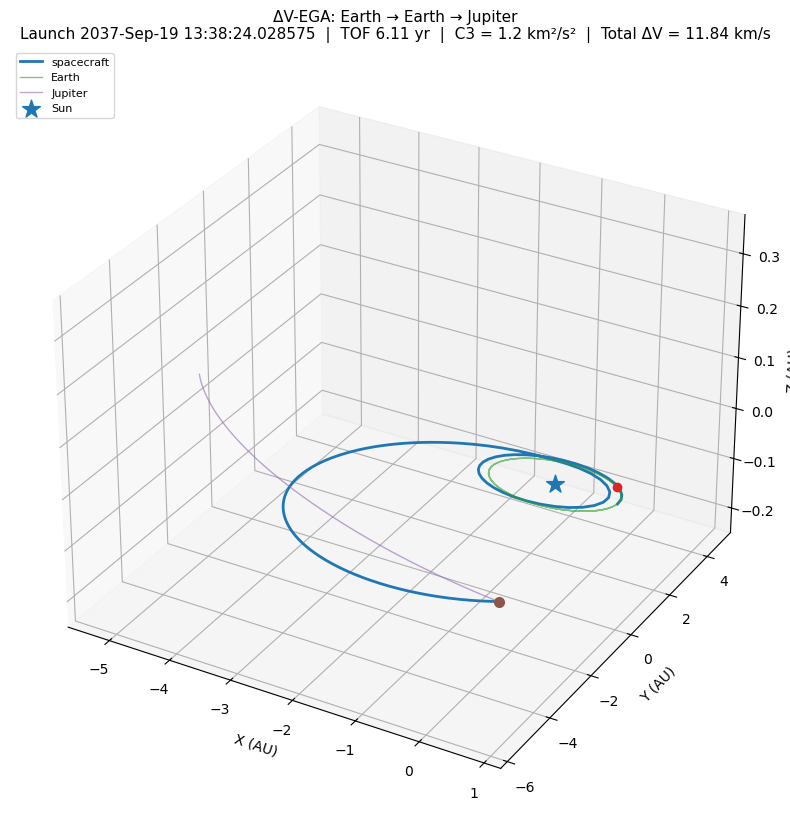

In [ ]:
# %% Cell 6 — animate trajectory + moving Earth/Jupiter
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import pykep as pk
from pykep import AU, propagate_lagrangian

# -----------------------
# knobs (lower quality = smaller/faster)
# -----------------------
fps = 12
days_per_frame = 12          # bigger = fewer frames
max_frames = 450             # hard cap

# -----------------------
# rebuild time grid (seconds)
# -----------------------
dt1_dsm   = etas[0] * T[0] * 86400.0
dt1_post  = (1 - etas[0]) * T[0] * 86400.0
dt2_total = T[1] * 86400.0

t_total = dt1_dsm + dt1_post + dt2_total
seconds_per_frame = days_per_frame * 86400.0
n_frames = int(min(max_frames, np.ceil(t_total / seconds_per_frame))) + 1
t_grid = np.linspace(0.0, t_total, n_frames)

# -----------------------
# spacecraft trajectory states (AU)
# -----------------------
xs = np.zeros(n_frames)
ys = np.zeros(n_frames)
zs = np.zeros(n_frames)

# moving planets (AU)
xe = np.zeros(n_frames); ye = np.zeros(n_frames); ze = np.zeros(n_frames)
xj = np.zeros(n_frames); yj = np.zeros(n_frames); zj = np.zeros(n_frames)

# epoch helper: absolute mjd2000 at time t (sec)
def mjd_at(tsec):
    return t0_mjd + tsec / 86400.0

for k, t in enumerate(t_grid):
    # spacecraft
    if t <= dt1_dsm:
        r, _ = propagate_lagrangian(r0, v0, t, pk.MU_SUN)
    elif t <= dt1_dsm + dt1_post:
        r, _ = propagate_lagrangian(r1_dsm, v1_post_dsm, t - dt1_dsm, pk.MU_SUN)
    else:
        r, _ = propagate_lagrangian(r1_end, v2_depart, t - (dt1_dsm + dt1_post), pk.MU_SUN)

    xs[k] = r[0] / AU; ys[k] = r[1] / AU; zs[k] = r[2] / AU

    # planets at same time
    ep = pk.epoch(mjd_at(t), "mjd2000")
    re, _ = seq[0].eph(ep)  # Earth
    rj, _ = seq[2].eph(ep)  # Jupiter

    xe[k] = re[0] / AU; ye[k] = re[1] / AU; ze[k] = re[2] / AU
    xj[k] = rj[0] / AU; yj[k] = rj[1] / AU; zj[k] = rj[2] / AU

# -----------------------
# figure
# -----------------------
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection="3d")

# spacecraft path + marker
(sc_line,) = ax.plot([], [], [], linewidth=2, label="spacecraft")
(sc_dot,)  = ax.plot([], [], [], marker="o", markersize=5, linestyle="")

# Earth/Jupiter trails + markers
(tr_e,) = ax.plot([], [], [], linewidth=1, alpha=0.6, label="Earth")
(pt_e,) = ax.plot([], [], [], marker="o", markersize=6, linestyle="")

(tr_j,) = ax.plot([], [], [], linewidth=1, alpha=0.6, label="Jupiter")
(pt_j,) = ax.plot([], [], [], marker="o", markersize=7, linestyle="")

# Sun
ax.scatter([0], [0], [0], s=180, marker="*", label="Sun", zorder=10)

ax.set_xlabel("X (AU)")
ax.set_ylabel("Y (AU)")
ax.set_zlabel("Z (AU)")
ax.legend(fontsize=8, loc="upper left")

ax.set_title(
    f'ΔV-EGA: Earth → Earth → Jupiter\n'
    f'Launch {launch_epoch}  |  TOF {total_tof/365.25:.2f} yr  |  '
    f'C3 = {c3_dep:.1f} km²/s²  |  Total ΔV = {best_f/1000:.2f} km/s',
    fontsize=11
)

# bounds (include planets)
pad = 0.25
allx = np.concatenate([xs, xe, xj])
ally = np.concatenate([ys, ye, yj])
allz = np.concatenate([zs, ze, zj])
ax.set_xlim(allx.min()-pad, allx.max()+pad)
ax.set_ylim(ally.min()-pad, ally.max()+pad)
ax.set_zlim(allz.min()-pad, allz.max()+pad)

trail_len = 80  # frames of trail behind planet markers (tune)

def init():
    for obj in [sc_line, sc_dot, tr_e, pt_e, tr_j, pt_j]:
        obj.set_data([], [])
        obj.set_3d_properties([])
    return sc_line, sc_dot, tr_e, pt_e, tr_j, pt_j

def update(i):
    # spacecraft
    sc_line.set_data(xs[:i+1], ys[:i+1])
    sc_line.set_3d_properties(zs[:i+1])
    sc_dot.set_data([xs[i]], [ys[i]])
    sc_dot.set_3d_properties([zs[i]])

    # planet trails (short window)
    j0 = max(0, i - trail_len)

    tr_e.set_data(xe[j0:i+1], ye[j0:i+1])
    tr_e.set_3d_properties(ze[j0:i+1])
    pt_e.set_data([xe[i]], [ye[i]])
    pt_e.set_3d_properties([ze[i]])

    tr_j.set_data(xj[j0:i+1], yj[j0:i+1])
    tr_j.set_3d_properties(zj[j0:i+1])
    pt_j.set_data([xj[i]], [yj[i]])
    pt_j.set_3d_properties([zj[i]])

    return sc_line, sc_dot, tr_e, pt_e, tr_j, pt_j

anim = FuncAnimation(fig, update, frames=n_frames, init_func=init, interval=1000/fps, blit=True)

gif_path = "output/02_trajectory_dvega.gif"
anim.save(gif_path, writer=PillowWriter(fps=fps))
print(f"Saved: {gif_path}")

plt.show()

In [16]:
# %% Cell 7 — Convergence diagnostics
print("Solution vector breakdown (converted to physical units):")
print(f"  t0 (mjd2000):     {best_x[0]:.2f} → {launch_epoch}")
print(f"  u (V∞ dir cosine): {best_x[1]:.4f}")
print(f"  v (V∞ dir cosine): {best_x[2]:.4f}")
print(f"  V∞ dep:            {best_x[3]:.1f} m/s = {best_x[3]/1000:.3f} km/s")
print(f"  η1 (DSM1 timing):  {best_x[4]:.4f} (fraction of leg 1)")
print(f"  T1 (leg 1 TOF):    {best_x[5]:.1f} days = {best_x[5]/365.25:.2f} yr")
print(f"  β2 (flyby plane):  {best_x[6]:.4f} rad")
print(f"  rp2/rV2 (flyby periapsis ratio): {best_x[7]:.4f}")
print(f"  η2 (DSM2 timing):  {best_x[8]:.4f} (fraction of leg 2)")
print(f"  T2 (leg 2 TOF):    {best_x[9]:.1f} days = {best_x[9]/365.25:.2f} yr")

# Flyby altitude in km (from pretty output, but let's compute it)
earth_radius_km = 6378.0  # km
flyby_rp_ratio = best_x[7]  # periapsis radius / planet safe radius
# pykep uses the planet's safe_radius for this ratio
earth_safe_radius_km = seq[1].safe_radius / 1000.0  # convert m to km
flyby_alt_km = flyby_rp_ratio * earth_safe_radius_km - earth_radius_km
print(f"\n  Earth flyby periapsis ratio: {flyby_rp_ratio:.2f}")
print(f"  Earth safe radius (pykep): {earth_safe_radius_km:.0f} km")
print(f"  Flyby altitude: ~{flyby_alt_km:.0f} km")

# Bounds check (vinf in internal units: m/s)
print("\nBound checks:")
print(f"  T1: 200 ≤ {best_x[5]:.0f} ≤ 900  {'⚠ AT BOUND' if best_x[5] < 201 or best_x[5] > 899 else '✓'}")
print(f"  T2: 400 ≤ {best_x[9]:.0f} ≤ 2200  {'⚠ AT BOUND' if best_x[9] < 401 or best_x[9] > 2199 else '✓'}")
vinf_kms = best_x[3] / 1000
print(f"  V∞: 0.5 ≤ {vinf_kms:.2f} ≤ 6.0 km/s  {'⚠ AT BOUND' if vinf_kms < 0.51 or vinf_kms > 5.99 else '✓'}")

Solution vector breakdown (converted to physical units):
  t0 (mjd2000):     13776.57 → 2037-Sep-19 13:38:24.028575
  u (V∞ dir cosine): 0.2387
  v (V∞ dir cosine): 0.5010
  V∞ dep:            1100.3 m/s = 1.100 km/s
  η1 (DSM1 timing):  0.4398 (fraction of leg 1)
  T1 (leg 1 TOF):    471.9 days = 1.29 yr
  β2 (flyby plane):  -1.5222 rad
  rp2/rV2 (flyby periapsis ratio): 1.1000
  η2 (DSM2 timing):  0.4180 (fraction of leg 2)
  T2 (leg 2 TOF):    1760.5 days = 4.82 yr

  Earth flyby periapsis ratio: 1.10
  Earth safe radius (pykep): 7016 km
  Flyby altitude: ~1339 km

Bound checks:
  T1: 200 ≤ 472 ≤ 900  ✓
  T2: 400 ≤ 1761 ≤ 2200  ✓
  V∞: 0.5 ≤ 1.10 ≤ 6.0 km/s  ✓
